In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
file_path = '/content/cancer-risk-factors.csv'
df = pd.read_csv(file_path)

In [3]:
df

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,ST0395,Colon,60,1,4,6,4,0,10,6,...,4,5,3,1,0,4,0.437539,30.3,3,Medium
1996,ST0396,Prostate,84,1,5,7,8,0,10,0,...,2,1,3,0,0,2,0.451128,25.9,4,Medium
1997,ST0397,Lung,65,0,7,2,10,0,4,2,...,3,6,0,0,1,0,0.295760,22.5,3,Low
1998,ST0398,Lung,64,1,10,2,10,0,2,10,...,5,4,2,0,0,10,0.422201,25.3,3,Medium


In [4]:
df.columns

Index(['Patient_ID', 'Cancer_Type', 'Age', 'Gender', 'Smoking', 'Alcohol_Use',
       'Obesity', 'Family_History', 'Diet_Red_Meat', 'Diet_Salted_Processed',
       'Fruit_Veg_Intake', 'Physical_Activity', 'Air_Pollution',
       'Occupational_Hazards', 'BRCA_Mutation', 'H_Pylori_Infection',
       'Calcium_Intake', 'Overall_Risk_Score', 'BMI',
       'Physical_Activity_Level', 'Risk_Level'],
      dtype='object')

In [5]:
df.isnull().sum()

,0
Patient_ID,0
Cancer_Type,0
Age,0
Gender,0
Smoking,0
Alcohol_Use,0
Obesity,0
Family_History,0
Diet_Red_Meat,0
Diet_Salted_Processed,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
counts = df['Patient_ID'].value_counts().reset_index()
counts.columns = ['Patient_ID','count']
counts

,Patient_ID,count
0,ST0383,1
1,ST0382,1
2,ST0381,1
3,ST0380,1
4,ST0379,1
...,...,...
1995,LU0004,1
1996,LU0003,1
1997,LU0002,1
1998,LU0001,1


In [8]:
counts = df['Cancer_Type'].value_counts().reset_index()
counts.columns = ['Cancer_Type','count']
counts

,Cancer_Type,count
0,Lung,527
1,Breast,460
2,Colon,418
3,Prostate,305
4,Skin,290


In [9]:
counts = df['Age'].value_counts().reset_index()
counts.columns = ['Age','count']
counts

,Age,count
0,64,85
1,65,85
2,68,81
3,60,81
4,67,77
...,...,...
56,25,2
57,36,1
58,31,1
59,29,1


In [10]:
counts = df['Gender'].value_counts().reset_index()
counts.columns = ['Gender','count']
counts

,Gender,count
0,0,1022
1,1,978


In [11]:
counts = df['Smoking'].value_counts().reset_index()
counts.columns = ['Smoking','count']
counts

,Smoking,count
0,10,343
1,6,267
2,1,204
3,3,175
4,2,174
5,0,169
6,5,166
7,4,166
8,9,126
9,8,107


In [12]:
counts = df['Alcohol_Use'].value_counts().reset_index()
counts.columns = ['Alcohol_Use','count']
counts

,Alcohol_Use,count
0,7,220
1,2,210
2,0,204
3,9,197
4,8,195
5,1,186
6,10,183
7,6,183
8,3,151
9,4,145


In [13]:
counts = df['Obesity'].value_counts().reset_index()
counts.columns = ['Obesity','count']
counts

,Obesity,count
0,10,348
1,6,217
2,5,210
3,8,208
4,4,208
5,7,190
6,9,181
7,2,121
8,0,109
9,1,109


In [14]:
counts = df['Family_History'].value_counts().reset_index()
counts.columns = ['Family_History','count']
counts

,Family_History,count
0,0,1611
1,1,389


In [15]:
counts = df['Diet_Red_Meat'].value_counts().reset_index()
counts.columns = ['Diet_Red_Meat', 'count']
counts

,Diet_Red_Meat,count
0,10,261
1,5,206
2,7,201
3,6,189
4,4,188
5,3,180
6,2,170
7,1,169
8,0,153
9,8,150


In [16]:
counts = df['Diet_Salted_Processed'].value_counts().reset_index()
counts.columns = ['Diet_Salted_Processed','count']
counts

,Diet_Salted_Processed,count
0,4,260
1,3,253
2,2,229
3,1,187
4,0,184
5,10,182
6,6,167
7,5,151
8,9,136
9,7,126


In [17]:
counts = df['Diet_Salted_Processed'].value_counts().reset_index()
counts.columns = ['Diet_Salted_Processed','count']
counts

,Diet_Salted_Processed,count
0,4,260
1,3,253
2,2,229
3,1,187
4,0,184
5,10,182
6,6,167
7,5,151
8,9,136
9,7,126


In [18]:
counts = df['Fruit_Veg_Intake'].value_counts().reset_index()
counts.columns = ['Fruit_Veg_Intake','count']
counts

,Fruit_Veg_Intake,count
0,4,214
1,3,214
2,6,214
3,5,210
4,8,195
5,0,186
6,10,162
7,1,159
8,7,154
9,2,146


In [19]:
counts = df['Physical_Activity'].value_counts().reset_index()
counts.columns = ['Physical_Activity','count']
counts

,Physical_Activity,count
0,1,261
1,3,254
2,4,246
3,0,242
4,2,225
5,5,173
6,6,152
7,8,117
8,10,112
9,7,111


In [20]:
counts = df['Air_Pollution'].value_counts().reset_index()
counts.columns = ['Air_Pollution','count']
counts

,Air_Pollution,count
0,10,310
1,4,243
2,3,211
3,8,172
4,5,169
5,6,161
6,2,160
7,0,148
8,7,144
9,9,143


In [21]:
counts = df['Occupational_Hazards'].value_counts().reset_index()
counts.columns = ['Occupational_Hazards','count']
counts

,Occupational_Hazards,count
0,5,243
1,10,238
2,4,212
3,0,192
4,1,182
5,3,173
6,9,168
7,2,164
8,6,152
9,7,146


In [22]:
counts = df['BRCA_Mutation'].value_counts().reset_index()
counts.columns = ['BRCA_Mutation','count']
counts

,BRCA_Mutation,count
0,0,1935
1,1,65


In [23]:
counts = df['H_Pylori_Infection'].value_counts().reset_index()
counts.columns = ['H_Pylori_Infection','count']
counts

,H_Pylori_Infection,count
0,0,1607
1,1,393


In [24]:
counts = df['Calcium_Intake'].value_counts().reset_index()
counts.columns = ['Calcium_Intake','count']
counts

,Calcium_Intake,count
0,0,355
1,1,210
2,5,205
3,4,202
4,2,201
5,3,192
6,6,181
7,7,166
8,10,110
9,8,90


In [25]:
counts = df['Overall_Risk_Score'].value_counts().reset_index()
counts.columns = ['Overall_Risk_Score','count']
counts

,Overall_Risk_Score,count
0,0.527490,1
1,0.423093,1
2,0.174458,1
3,0.653971,1
4,0.493528,1
...,...,...
1995,0.524358,1
1996,0.318449,1
1997,0.605082,1
1998,0.424299,1


In [26]:
counts = df['BMI'].value_counts().reset_index()
counts.columns = ['BMI','count']
counts

,BMI,count
0,25.9,34
1,26.3,26
2,26.8,25
3,25.0,25
4,26.7,24
...,...,...
203,17.3,1
204,34.9,1
205,15.9,1
206,36.6,1


In [27]:
counts = df['Physical_Activity_Level'].value_counts().reset_index()
counts.columns = ['Physical_Activity_Level','count']
counts

,Physical_Activity_Level,count
0,0,214
1,5,204
2,7,195
3,9,191
4,2,188
5,6,177
6,3,172
7,4,171
8,8,166
9,10,165


In [28]:
counts = df['Risk_Level'].value_counts().reset_index()
counts.columns = ['Risk_Level','count']
counts

,Risk_Level,count
0,Medium,1574
1,Low,324
2,High,102


In [29]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [30]:
df['encoded_Patient_ID'] = le.fit_transform(df['Patient_ID'])

In [31]:
df['encoded_Cancer_Type'] = le.fit_transform(df['Cancer_Type'])

In [32]:
df['encoded_Risk_Level'] = le.fit_transform(df['Risk_Level'])

In [33]:
counts = df['encoded_Patient_ID'].value_counts().reset_index()
counts.columns = ['encoded_Patient_ID','count']
counts

,encoded_Patient_ID,count
0,1983,1
1,1982,1
2,1981,1
3,1980,1
4,1979,1
...,...,...
1995,804,1
1996,803,1
1997,802,1
1998,801,1


In [34]:
x = df.drop(['Patient_ID', 'Cancer_Type', 'Risk_Level', 'encoded_Patient_ID', 'Overall_Risk_Score', 'encoded_Risk_Level'], axis=1)
y = df['encoded_Risk_Level']
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=143)

In [35]:
df.columns

Index(['Patient_ID', 'Cancer_Type', 'Age', 'Gender', 'Smoking', 'Alcohol_Use',
       'Obesity', 'Family_History', 'Diet_Red_Meat', 'Diet_Salted_Processed',
       'Fruit_Veg_Intake', 'Physical_Activity', 'Air_Pollution',
       'Occupational_Hazards', 'BRCA_Mutation', 'H_Pylori_Infection',
       'Calcium_Intake', 'Overall_Risk_Score', 'BMI',
       'Physical_Activity_Level', 'Risk_Level', 'encoded_Patient_ID',
       'encoded_Cancer_Type', 'encoded_Risk_Level'],
      dtype='object')

In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [37]:
algorithms = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine (SVC)": SVC(),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(),
    "Naive Bayes (GaussianNB)": GaussianNB()
}

In [38]:
results = {}
for name, algo in algorithms.items():
    algo.fit(x_train, y_train)
    y_pred = algo.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"\n--- {name} ---")
    print(f"Accuracy: {accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Logistic Regression ---
Accuracy: 0.8167

--- Decision Tree ---
Accuracy: 0.7433

--- Random Forest ---
Accuracy: 0.8417

--- Support Vector Machine (SVC) ---
Accuracy: 0.7867

--- K-Nearest Neighbors (KNN) ---
Accuracy: 0.8100

--- Naive Bayes (GaussianNB) ---
Accuracy: 0.8300


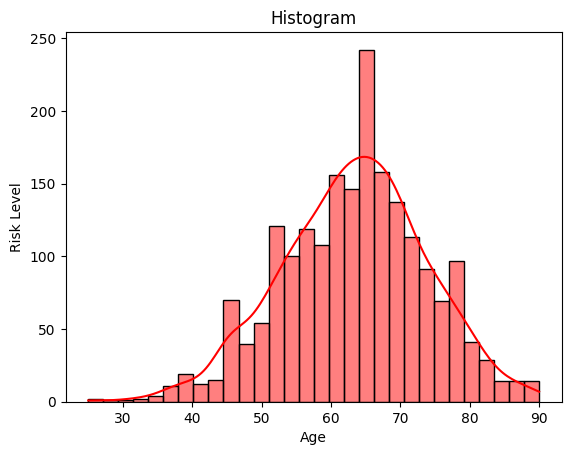

In [39]:
sns.histplot(data=df, x='Age', bins=30, kde=True, color='red')
plt.title('Histogram')
plt.xlabel('Age')
plt.ylabel('Risk Level')
plt.show()

In [40]:
def fun():
  Age = int(input("Enter Age: "))
  Gender = int(input("Enter The Gender: "))
  Smoking = int(input("Enter The Smoking: "))
  Alcohol_Use = int(input("Enter The Alcohol Use: "))
  Obesity = int(input("Enter The Obesity: "))
  Family_History = int(input("Enter Family History: "))
  Diet_Red_Meat = int(input("Enter The Diet Red Meat: "))
  Diet_Salted_Processed = int(input("Enter Diet Salted Processed: "))
  Fruit_Veg_Intake = int(input("Enter Fruit Veg Intake: "))
  Physical_Activity = int(input("Enter Physical Activity: "))
  Air_Pollution = int(input("Enter Air Pollution: "))
  Occupational_Hazards = int(input("Enter Occupational Hazards: "))
  BRCA_Mutation = int(input("Enter BRCA Mutation: "))
  H_Pylori_Infection = int(input("Enter H Pylori Infection: "))
  Calcium_Intake = int(input("Enter Calcium Intake: "))
  BMI = int(input("Enter BMI: "))
  Physical_Activity_Level = int(input("Enter Physical Activity Level: "))

  Test_Value = [(Age, Gender, Smoking, Alcohol_Use,
       Obesity, Family_History, Diet_Red_Meat, Diet_Salted_Processed,
       Fruit_Veg_Intake, Physical_Activity, Air_Pollution,
       Occupational_Hazards, BRCA_Mutation, H_Pylori_Infection,
       Calcium_Intake, BMI,
       Physical_Activity_Level)]
  print(algorithms["K-Nearest Neighbors (KNN)"].predict(Test_Value))

In [41]:
import pickle
filename = 'svm_model_for_cancer.sav'
model = algorithms["Support Vector Machine (SVC)"] # Assign the SVC model to 'model'
pickle.dump(model, open(filename, 'wb'))

In [42]:
load_model = pickle.load(open('svm_model_for_cancer.sav','rb'))

In [43]:
load_model.predict(x_test)

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2,
       1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [ ]:
fun()